In this notebook I check consistency of my code and results from Risk Institute of EDHEC.


Inputs:
- parameters for stochastic simulations

<img src="pictures/Initial_parameters_extended.png" width="400">

[Article](https://climateimpact.edhec.edu/sites/ercii/files/edhec-publication-hedging-versus-insurance-f_1363854879761-pdfjpg.pdf)
- inputs for period t=0 are taken as long term values of SR, stock returns, volatility and risk free rate
- apart from reported correlations I use correlation of interest rate with other parameters = 0; correlation of stock volatility and shar[e rati0 = +76.7%
- 20 years investment horizon
- 100 initial wealth
- 0.1 invested in risky asset and 0.9 invested in zero-coupon bond
- b_Q = b+(σ_r*λ_r)/a (actual long term interest rate under risk-neutral measure is different)

In [2]:
0.0306-0.53*0.0098/0.13

-0.009353846153846154

## Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import market_stochastic_simulation as mss
import retirement_client as pensioner

# 1. Market Simulation Code

$
\begin{cases}
r_{t+dt} = r_t + \kappa_r (\bar{lt_r} - r_t) dt + \sigma_r \sqrt{dt} Z_t^r\\
SR_{t+dt} = SR_t + \kappa_sr (\bar{lt_sr} - SR_t) dt + \sigma_SR \sqrt{dt} Z_t^SR\\
V_{t+dt} = V_t + \kappa_v (lt_V - V_t) dt + \sigma_V \sqrt{V_t} \sqrt{dt} Z_t^V\\
S_{t+dt} = S_t \times \exp \left( \left( r + \bar{\lambda_0} \sigma_t - \frac{1}{2} \sigma_t^2 \right) dt + \sigma_t \sqrt{dt} Z_t^S \right) \\
\end{cases}
$

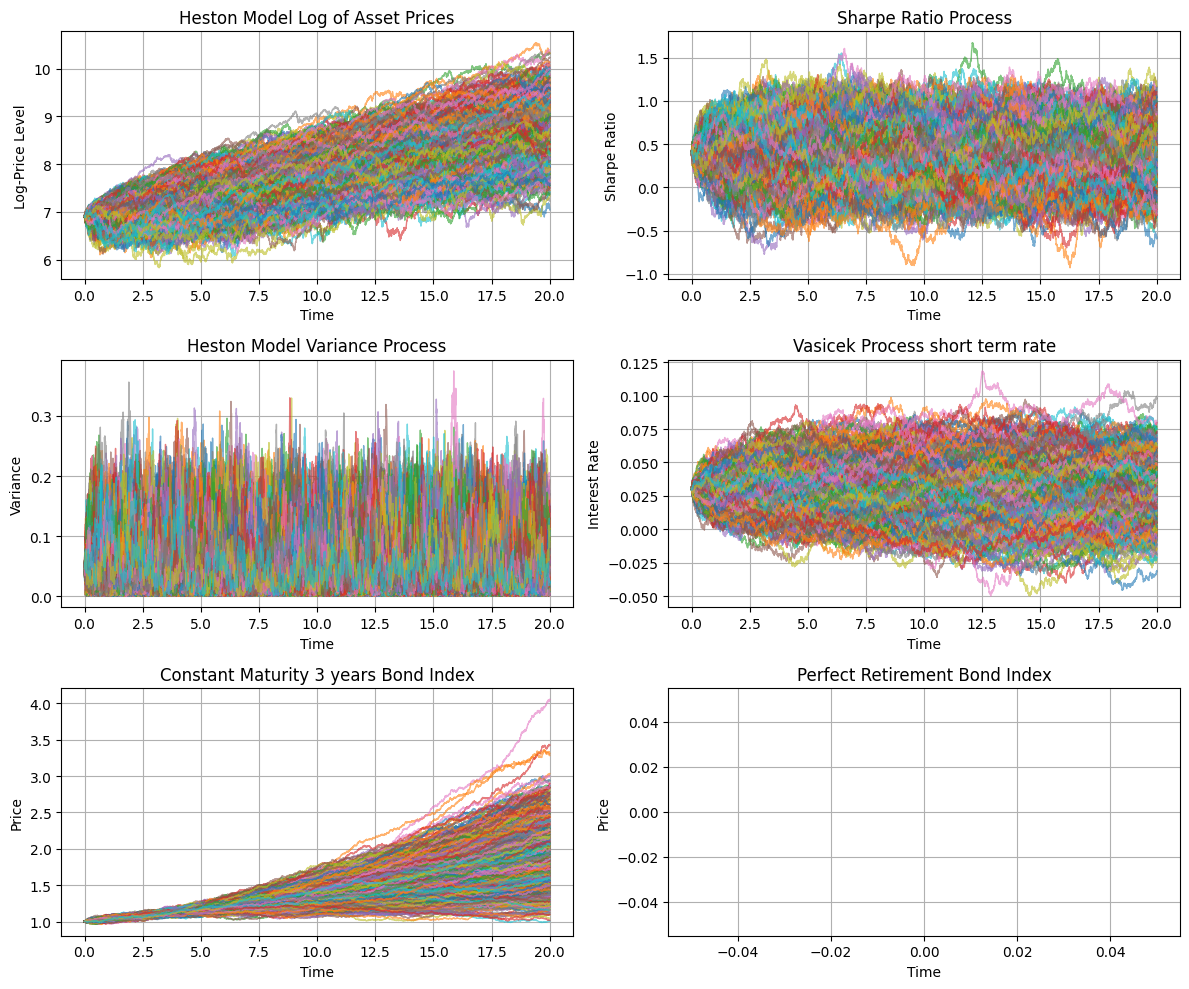

In [4]:
# Parameters
S0 = 1000.0              # asset price
T = 20                  # time in years
N = 252*T              # number of time steps in simulation
M = 1000                # number of simulated paths
seed = 124              # simulation seed

simulated_market = mss.MarketSimulator(T,N,M,seed, S0, lambda_r = 0)
simulated_market.plot_market_simulation()

In [5]:
simulated_market.lt_r_q

0.0306

## Initialize client

Find cash flows the client needs

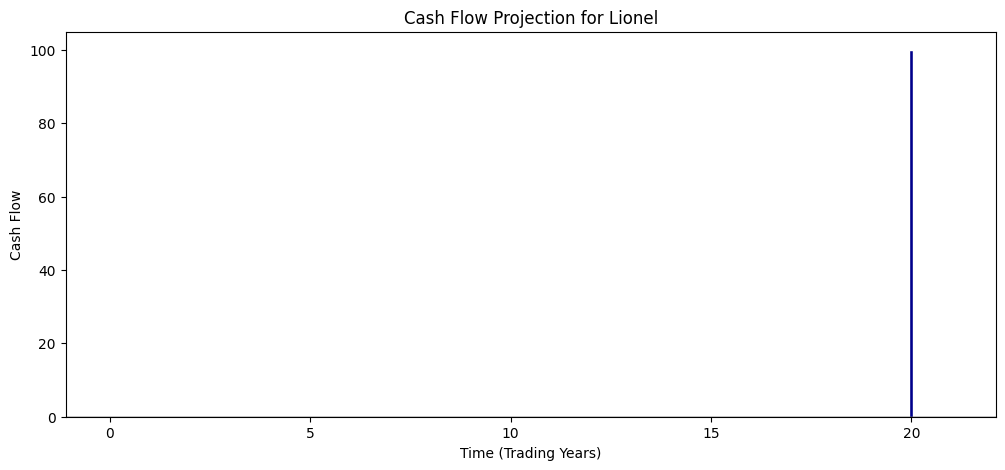

In [6]:
client = pensioner.RetirementClient("Lionel",
                           accumulation_years=20,
                           accumulation_cash_flow=0,
                           decumulation_years=1,
                           decumulation_cash_flow=100,
                           periodicity = 12)

client.plot_cash_flows()

Now we know cash flows that the client needs. Hence, we can simulate perfect zero coupon bond for him

In [7]:
simulated_market.calculate_perfect_retirement_bond(client)

Simulating scenarios: 100%|█████████████████| 1000/1000 [03:40<00:00,  4.53it/s]
/Users/aleksandrmikhailov/Desktop/GitHub_EDHEC/Retirement solution/Goal-Based-Investing/market_stochastic_simulation.py:295: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  retirement_bond_p.loc[:, simulation_number] = result[i]


Plot the market and the zero coupon bond.

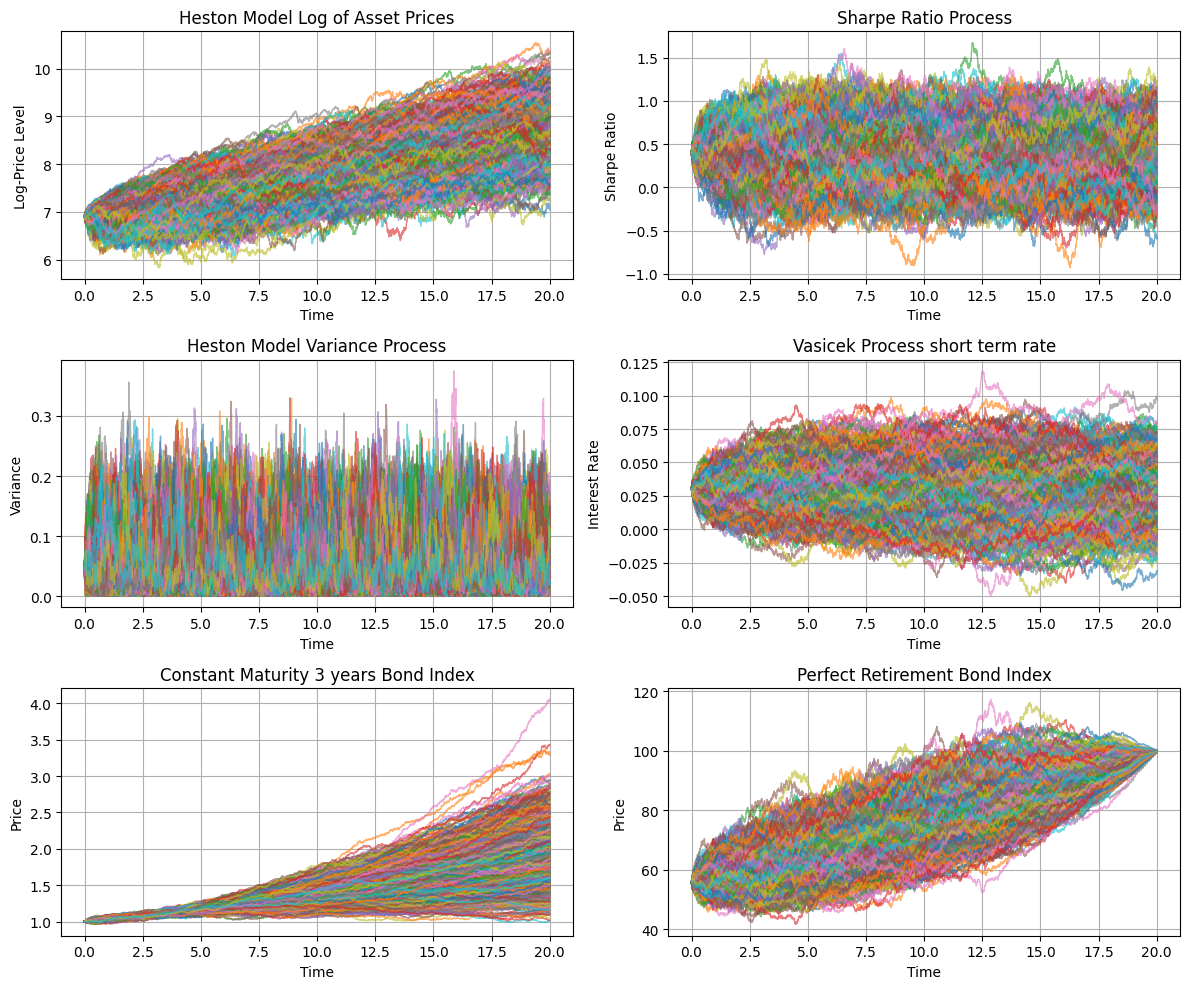

In [8]:
simulated_market.plot_market_simulation()

## Find fixed mix fund performance (rebalanced daily)

In [9]:
risky_asset_returns  = simulated_market.S_p.pct_change().iloc[1:,:]
safe_asset_returns  = simulated_market.retirement_bond_p.pct_change().iloc[1:,:]

In [10]:
FM_fund_performance_0 = risky_asset_returns*0+safe_asset_returns*1
FM_fund_performance_10 = risky_asset_returns*0.1+safe_asset_returns*0.9
FM_fund_performance_20 = risky_asset_returns*0.2+safe_asset_returns*0.8
FM_fund_performance_30 = risky_asset_returns*0.3+safe_asset_returns*0.7

initial_wealth = 100

portfolio_wealth_0 = (FM_fund_performance_0+1).cumprod()*100
portfolio_wealth_10 = (FM_fund_performance_10+1).cumprod()*100
portfolio_wealth_20 = (FM_fund_performance_20+1).cumprod()*100
portfolio_wealth_30 = (FM_fund_performance_30+1).cumprod()*100

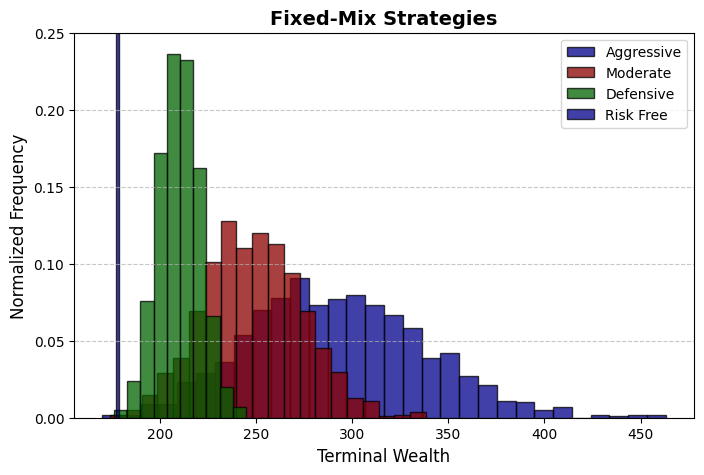

In [11]:
# Create figure
plt.figure(figsize=(8, 5))

# Define colors and labels
colors = ["darkblue", "darkred", "darkgreen", "darkblue"]
labels = ["Aggressive", "Moderate", "Defensive", "Risk Free"]
bins_list = [30, 20, 10, 1]  # Different bin sizes

# Iterate over each strategy
for i, (portfolio, bins, color, label) in enumerate(zip(
    [portfolio_wealth_30, portfolio_wealth_20, portfolio_wealth_10, portfolio_wealth_0], 
    bins_list, colors, labels)):

    # Compute histogram data (without density=True)
    n, bins = np.histogram(portfolio.iloc[-1, :], bins=bins)
    
    # Normalize so the sum is 1
    n = n / n.sum()

    # Plot manually using plt.bar
    plt.bar(bins[:-1], n, width=np.diff(bins), color=color, edgecolor="black", alpha=0.75, label=label)

# Titles and Labels
plt.title("Fixed-Mix Strategies", fontsize=14, fontweight='bold')
plt.xlabel("Terminal Wealth", fontsize=12)
plt.ylabel("Normalized Frequency", fontsize=12)

# Grid for readability
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Legend
plt.legend()

plt.ylim(0,0.25)
# Show the improved plot
plt.show()

In [12]:
portfolio_wealth_10.iloc[-1,:].mean().round(2)

213.54

Resulting wealth is the same as in the simulation results obtained in [article](https://climateimpact.edhec.edu/sites/ercii/files/edhec-publication-hedging-versus-insurance-f_1363854879761-pdfjpg.pdf)

<img src="pictures/New paper FM result.png" width="400">